# 📌 Predictive Maintenance with Industrial Sensors
# This notebook demonstrates a complete workflow to train, evaluate,
# and visualize a predictive maintenance model using XGBoost.

-----------------------------
 1️⃣ Import Libraries
-----------------------------
 We start by importing all necessary Python libraries.
 - pandas and numpy: for data manipulation
 - matplotlib and seaborn: for plotting
 - sklearn: for model evaluation, splitting, and metrics
 - xgboost: the XGBoost classifier
 - imblearn: SMOTE for handling imbalanced classes
 - joblib: to save the trained model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

# Set up aesthetics for plots

In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

 -----------------------------
 2️⃣ Load Dataset
 -----------------------------

# Load the CSV file containing sensor data and machine status (fail/no fail).

In [4]:
df = pd.read_csv("data.csv")

# Show first rows of the dataset to check its structure

In [5]:
print("First rows of the dataset:")
display(df.head())

First rows of the dataset:


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


 -----------------------------
 3️⃣ Separate Features and Target
 -----------------------------
 
# The feature matrix X contains all sensor readings and derived variables.
# The target vector y is the column we want to predict: "fail" (1) or "no fail" (0).

In [6]:
X = df.drop(columns=["fail"])  # Features
y = df["fail"]                 # Target

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
print("Target variable distribution:")
print(y.value_counts())

Shape of X (features): (944, 9)
Shape of y (target): (944,)
Target variable distribution:
fail
0    551
1    393
Name: count, dtype: int64


 -----------------------------
 4️⃣ Split Dataset into Training and Test Sets
 -----------------------------
# We split the data into training and test sets.
# - test_size=0.2 reserves 20% for testing
# - stratify=y ensures the class distribution is maintained
# - random_state=42 makes results reproducible

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

 -----------------------------
 5️⃣ Handle Class Imbalance with SMOTE
 -----------------------------
# In predictive maintenance, failure events are often rare.
# SMOTE creates synthetic examples of the minority class to balance the dataset.

In [8]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribution before SMOTE:\n", y_train.value_counts())
print("Distribution after SMOTE:\n", y_train_res.value_counts())

Distribution before SMOTE:
 fail
0    441
1    314
Name: count, dtype: int64
Distribution after SMOTE:
 fail
0    441
1    441
Name: count, dtype: int64


 -----------------------------
 6️⃣ Create and Train XGBoost Model
 -----------------------------
# XGBoost is highly effective for tabular data.
# Parameters:
# - n_estimators: number of trees
# - max_depth: depth of each tree
# - learning_rate: step size for updating weights
# - n_jobs=-1 uses all CPU cores
# - random_state ensures reproducibility

In [9]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# Train the model using the balanced training data
model.fit(X_train_res, y_train_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


 -----------------------------
 7️⃣ Make Predictions
 -----------------------------
# Predict class labels and probabilities for the test set

In [10]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

 -----------------------------
 8️⃣ Evaluate Model Performance
 -----------------------------
# Classification report provides precision, recall, f1-score
# Confusion matrix shows correct vs incorrect predictions
# ROC-AUC measures model's ability to separate classes
# PR-AUC is useful when classes are imbalanced
# Cross-validation F1 shows stability across folds

In [11]:
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

f1_scores = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring="f1")
print(f"F1 average (cross-validation): {f1_scores.mean():.3f}")

Classification Report:
              precision    recall  f1-score   support

           0      0.925     0.891     0.907       110
           1      0.855     0.899     0.877        79

    accuracy                          0.894       189
   macro avg      0.890     0.895     0.892       189
weighted avg      0.896     0.894     0.895       189

Confusion Matrix:
[[98 12]
 [ 8 71]]
ROC-AUC: 0.971
PR-AUC: 0.960
F1 average (cross-validation): 0.908


 -----------------------------
 9️⃣ Visualizations
 -----------------------------

# 9.1 Confusion Matrix
# Heatmap shows where the model predicts correctly or incorrectly

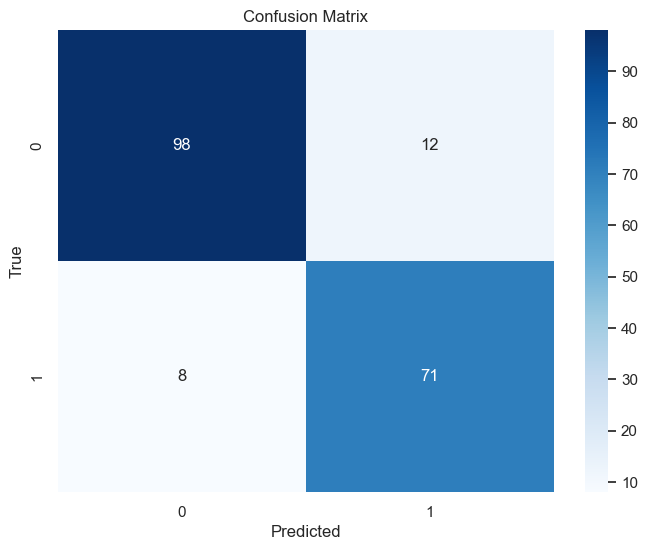

In [12]:
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 9.2 ROC Curve
# Visualizes tradeoff between True Positive Rate and False Positive Rate

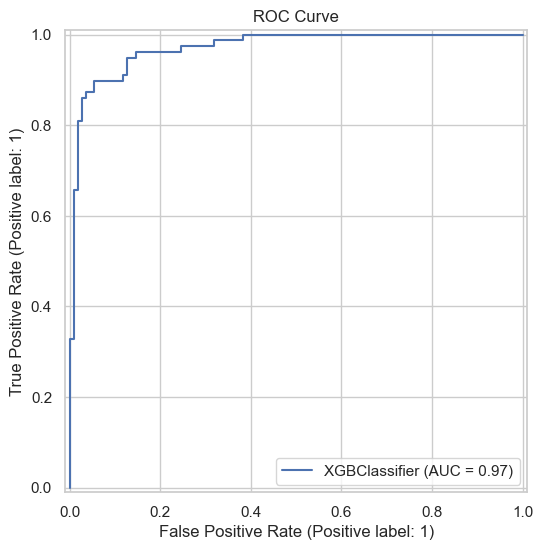

In [13]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

# 9.3 Precision-Recall Curve
# More informative when classes are imbalanced

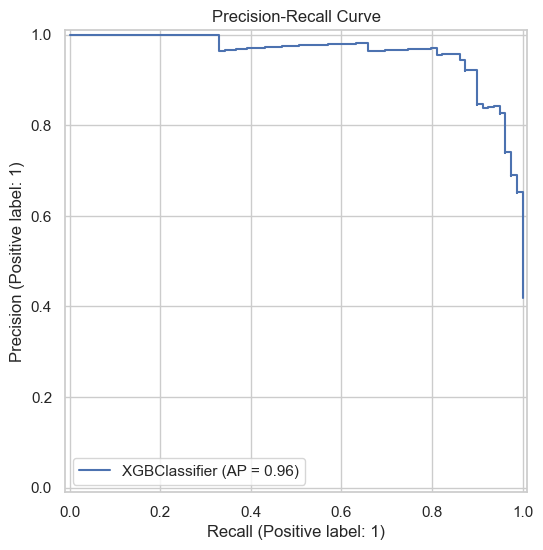

In [14]:
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
plt.title("Precision-Recall Curve")
plt.show()

# 9.4 Feature Importance
# Bar chart showing which sensors/features contribute most to predictions

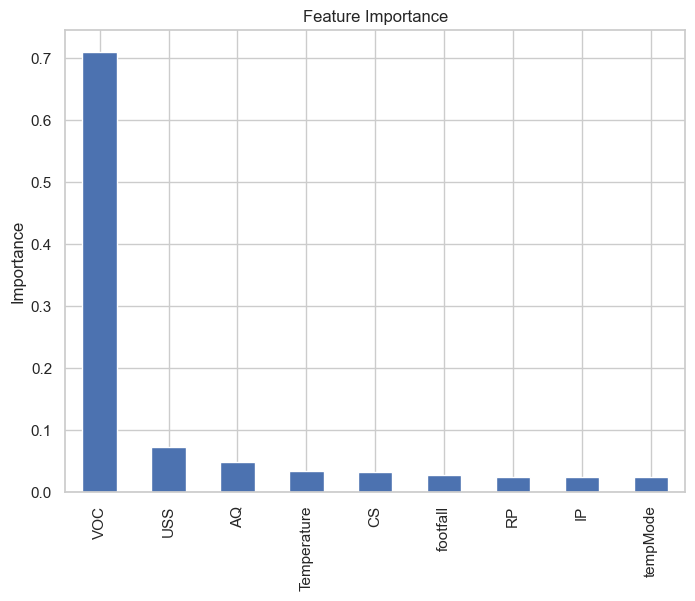

In [15]:
plt.figure()
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

 -----------------------------
 1️⃣0️⃣ Save Model
 -----------------------------
# Save the trained model to a file for later use or deployment

In [16]:
joblib.dump(model, "predictive_maintenance_model.joblib")
print("Model saved as 'predictive_maintenance_model.joblib'")

Model saved as 'predictive_maintenance_model.joblib'
